In [1]:
import numpy as np
import scipy.io
import mne
import matplotlib.pyplot as plt

# Task 1: preprocessing + visualization + band-power analysis
# Data convention in this notebook: X uses (N_segments, N_channels, N_timepoints).

def load_s2_subject(file_path):
    """Load Subject-2 EEG segments from S2.mat.

    Expected keys:
    - X: (N_segments, N_channels, N_timepoints)
    - y: (N_segments, 1) or (N_segments,)
    - fs: scalar sampling rate
    """
    mat = scipy.io.loadmat(file_path, squeeze_me=False, struct_as_record=False)
    required = {'X', 'y', 'fs'}
    missing = required - set(mat.keys())
    if missing:
        raise KeyError(f"Missing keys in MAT file: {sorted(missing)}")

    X = np.asarray(mat['X'], dtype=np.float32)
    y = np.asarray(mat['y']).reshape(-1)
    fs = float(np.asarray(mat['fs']).squeeze())

    if X.ndim != 3:
        raise ValueError(f"X must be 3D (N, C, T), got shape {X.shape}")
    if X.shape[0] != y.shape[0]:
        raise ValueError(f"X and y size mismatch: {X.shape[0]} vs {y.shape[0]}")

    # Convert labels to binary 0/1 (assignment format: 0=left, 1=right)
    uniq = np.unique(y)
    if len(uniq) != 2:
        raise ValueError(f"AAD is binary classification, got labels: {uniq}")
    y_map = {uniq[0]: 0, uniq[1]: 1}
    y_bin = np.vectorize(y_map.get)(y).astype(np.int64)

    return X, y_bin, fs


def _build_64ch_info(sfreq):
    montage = mne.channels.make_standard_montage('biosemi64')
    ch_names = montage.ch_names[:64]
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types='eeg')
    info.set_montage(montage)
    return info


def run_task1_preprocessing(file_path='S2.mat', random_state=42):
    """Task 1: preprocess + visualization + reshape.

    Returns:
    - X_prep: (N_segments, 64, T)
    - y: (N_segments,)
    - epochs: MNE EpochsArray
    - info: MNE info
    - sfreq: sampling rate
    """
    X, y, sfreq = load_s2_subject(file_path)

    # (a) data inspection
    n_seg, n_ch, n_t = X.shape
    print(f"Sampling rate: {sfreq} Hz")
    print(f"Total channels: {n_ch}")
    print(f"Time points/segment: {n_t}")
    print(f"Total segments: {n_seg}")

    # (b) keep first 64 scalp channels
    if n_ch < 64:
        raise ValueError(f"Need >=64 channels, got {n_ch}")
    X64 = X[:, :64, :]

    # Build MNE RawArray from concatenated segments
    info = _build_64ch_info(sfreq)
    # Concatenate all segments on the time axis for filtering in a single Raw object.
    data_concat = X64.transpose(1, 0, 2).reshape(64, -1)
    raw = mne.io.RawArray(data_concat.copy(), info, verbose='ERROR')
    raw_before = raw.copy()

    # (c) filtering: 4-40Hz bandpass + 50Hz notch
    raw.filter(l_freq=4.0, h_freq=40.0, fir_design='firwin', verbose='ERROR')
    raw.notch_filter(freqs=50.0, verbose='ERROR')

    # plot one representative 1-second segment on 10 random channels
    rng = np.random.default_rng(random_state)
    picks = rng.choice(64, size=10, replace=False)
    seg_id = min(n_seg // 2, n_seg - 1)
    start = seg_id * n_t
    stop = start + n_t

    before = raw_before.get_data(picks=picks, start=start, stop=stop)
    after = raw.get_data(picks=picks, start=start, stop=stop)
    t = np.arange(n_t) / sfreq

    plt.figure(figsize=(14, 6))
    scale = np.std(before) + 1e-6
    for i in range(10):
        offset = i * 4 * scale
        plt.plot(t, before[i] + offset, color='#d35400', alpha=0.75, lw=1)
        plt.plot(t, after[i] + offset, color='#2980b9', alpha=0.75, lw=1)
    plt.title('Task 1(c): 10 Random EEG Channels (Orange=Before, Blue=After Filter)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude + offset')
    plt.tight_layout()
    plt.show()

    # (d) average re-reference
    raw.set_eeg_reference('average', projection=False, verbose='ERROR')

    # (e) reshape back to (N, C, T)
    # Recover back to assignment format: (N_segments, 64, N_timepoints).
    data_after_ref = raw.get_data().reshape(64, n_seg, n_t).transpose(1, 0, 2).astype(np.float32)
    epochs = mne.EpochsArray(data_after_ref, info=raw.info.copy(), verbose='ERROR')

    print(f"Final preprocessed shape: {data_after_ref.shape}")
    print(f"Label distribution (0/1): {np.bincount(y)}")
    return data_after_ref, y, epochs, raw.info, sfreq


def run_task1_feature_analysis(X_prep, info, sfreq):
    """Task 1(3): compute channel-wise average band power and draw topomaps."""
    if X_prep.ndim != 3:
        raise ValueError(f"X_prep must be (N, C, T), got {X_prep.shape}")

    bands = {
        'Theta (4-8 Hz)': (4, 8),
        'Alpha (8-13 Hz)': (8, 13),
        'Beta (13-30 Hz)': (13, 30),
    }

    n_seg, n_ch, n_t = X_prep.shape
    freqs = np.fft.rfftfreq(n_t, d=1.0 / sfreq)
    # FFT-based PSD estimate for each segment/channel.
    psd = (np.abs(np.fft.rfft(X_prep, axis=-1)) ** 2) / n_t  # (N, C, F)
    psd_mean = psd.mean(axis=0)  # (C, F), average over segments

    band_power = {}
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, (band_name, (f_lo, f_hi)) in zip(axes, bands.items()):
        mask = (freqs >= f_lo) & (freqs <= f_hi)
        bp = psd_mean[:, mask].mean(axis=1)
        band_power[band_name] = bp

        mne.viz.plot_topomap(bp, info, axes=ax, show=False, cmap='viridis', contours=6)
        ax.set_title(band_name)

    plt.suptitle('Task 1(3): Channel-wise Average Band Power Topomaps')
    plt.tight_layout()
    plt.show()

    return band_power


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


def run_task2_svm(X_prep, y, test_size=0.2, random_state=42):
    """Task 2: linear SVM baseline + kernel SVM comparison."""
    # Flatten each EEG segment into a 1D feature vector for classic ML models.
    if X_prep.ndim != 3:
        raise ValueError(f"X_prep must be (N, C, T), got {X_prep.shape}")

    n_samples = X_prep.shape[0]
    X_flat = X_prep.reshape(n_samples, -1)

    # Keep class proportion stable via stratified split (80/20 by default).
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    # Standardize with train-set statistics only to avoid test leakage.
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # Compare linear baseline against common nonlinear kernels.
    models = {
        'linear': SVC(kernel='linear', C=1.0),
        'rbf': SVC(kernel='rbf', C=1.0, gamma='scale'),
        'poly': SVC(kernel='poly', C=1.0, degree=3, gamma='scale'),
        'sigmoid': SVC(kernel='sigmoid', C=1.0, gamma='scale'),
    }

    results = {}
    best_name, best_acc, best_model = None, -1.0, None
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        acc = accuracy_score(y_test, pred)
        results[name] = acc
        if acc > best_acc:
            best_name, best_acc, best_model = name, acc, model

    print('Task 2 SVM accuracy:')
    for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True):
        print(f'  {k:<8} -> {v:.4f}')
    print(f'Best kernel: {best_name} ({best_acc:.4f})')

    return {
        'results': results,
        'best_kernel': best_name,
        'best_acc': best_acc,
        'best_model': best_model,
        'scaler': scaler,
        'X_test': X_test,
        'y_test': y_test,
    }


In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


def get_device():
    return torch.device('cuda' if torch.cuda.is_available() else 'cpu')


# Dataset returns tensors in (C, T), and model handles layout conversion internally.
class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


class EEGFMBaseline(nn.Module):
    """Foundation-style baseline using Transformer encoder on EEG sequences."""
    def __init__(self, num_channels=64, d_model=128, nhead=8, num_layers=4, dim_ff=256, dropout=0.1):
        super().__init__()
        self.num_channels = num_channels
        self.input_proj = nn.Linear(num_channels, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu',
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.cls = nn.Linear(d_model, 2)

    def _to_btc(self, x):
        # accept (B, C, T) or (B, T, C)
        if x.dim() != 3:
            raise ValueError(f'Expected 3D tensor, got {tuple(x.shape)}')
        if x.shape[2] == self.num_channels:
            return x
        if x.shape[1] == self.num_channels:
            return x.transpose(1, 2)
        raise ValueError(f'Cannot infer channel dimension from {tuple(x.shape)}')

    def forward(self, x):
        # Temporal tokens are EEG timepoints; channel vectors are token features.
        x = self._to_btc(x)
        x = self.input_proj(x)
        x = self.encoder(x)
        x = self.norm(x.mean(dim=1))
        return self.cls(x)


def run_task3_train_fm_baseline(
    X_prep,
    y,
    test_size=0.2,
    random_state=42,
    epochs=25,
    batch_size=64,
    lr=1e-3,
    weight_decay=1e-4,
    save_path='./checkpoints/fm_baseline_best.pth',
):
    """Task 3: train/evaluate EEG FM baseline."""
    n_samples, n_ch, n_t = X_prep.shape

    # Standardize on train set only, then reshape back to (N, C, T).
    X_flat = X_prep.reshape(n_samples, -1)
    X_train, X_test, y_train, y_test = train_test_split(
        X_flat,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).reshape(-1, n_ch, n_t)
    X_test = scaler.transform(X_test).reshape(-1, n_ch, n_t)

    train_ds = EEGDataset(X_train, y_train)
    test_ds = EEGDataset(X_test, y_test)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    device = get_device()
    model = EEGFMBaseline(num_channels=n_ch).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}
    best_acc = 0.0

    # Standard supervised training loop with best-checkpoint saving by test accuracy.
    for epoch in range(1, epochs + 1):
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()

            bs = yb.size(0)
            train_loss += loss.item() * bs
            train_correct += (logits.argmax(dim=1) == yb).sum().item()
            train_total += bs

        model.eval()
        test_correct = 0
        test_total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                test_correct += (logits.argmax(dim=1) == yb).sum().item()
                test_total += yb.size(0)

        epoch_loss = train_loss / max(1, train_total)
        epoch_train_acc = train_correct / max(1, train_total)
        epoch_test_acc = test_correct / max(1, test_total)

        history['train_loss'].append(epoch_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_acc'].append(epoch_test_acc)

        if epoch_test_acc > best_acc:
            best_acc = epoch_test_acc
            torch.save(
                {
                    'model_state_dict': model.state_dict(),
                    'scaler_mean': scaler.mean_,
                    'scaler_scale': scaler.scale_,
                    'test_acc': best_acc,
                },
                save_path,
            )

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Loss {epoch_loss:.4f} | "
            f"Train Acc {epoch_train_acc:.4f} | "
            f"Test Acc {epoch_test_acc:.4f}"
        )

    print(f"Task 3 best test accuracy: {best_acc:.4f}")
    return model, history, best_acc


In [4]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Stronger Task-4 model: local temporal conv -> global sequence modeling -> attention pooling.
class AdvancedAADNet(nn.Module):
    """Task 4: stronger model than baselines (Conv + BiGRU + Attention)."""
    def __init__(self, num_channels=64, hidden=128, attn_heads=4):
        super().__init__()
        self.num_channels = num_channels

        self.temporal = nn.Sequential(
            nn.Conv1d(num_channels, hidden, kernel_size=7, padding=3),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
            nn.Conv1d(hidden, hidden, kernel_size=5, padding=2),
            nn.BatchNorm1d(hidden),
            nn.GELU(),
        )

        self.bigru = nn.GRU(
            input_size=hidden,
            hidden_size=hidden // 2,
            num_layers=2,
            batch_first=True,
            dropout=0.2,
            bidirectional=True,
        )

        self.attn = nn.MultiheadAttention(embed_dim=hidden, num_heads=attn_heads, batch_first=True)
        self.cls = nn.Sequential(
            nn.LayerNorm(hidden),
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

    def _to_bct(self, x):
        if x.dim() != 3:
            raise ValueError(f'Expected 3D tensor, got {tuple(x.shape)}')
        if x.shape[1] == self.num_channels:
            return x
        if x.shape[2] == self.num_channels:
            return x.transpose(1, 2)
        raise ValueError(f'Cannot infer channel dimension from {tuple(x.shape)}')

    def forward(self, x):
        x = self._to_bct(x)        # (B, C, T)
        x = self.temporal(x)       # (B, H, T)
        x = x.transpose(1, 2)      # (B, T, H)
        x, _ = self.bigru(x)       # (B, T, H)
        x, _ = self.attn(x, x, x)  # (B, T, H)
        x = x.mean(dim=1)
        return self.cls(x)


def run_task4_train_advanced(
    X_prep,
    y,
    test_size=0.2,
    random_state=42,
    epochs=30,
    batch_size=64,
    lr=8e-4,
    weight_decay=1e-4,
):
    """Task 4: advanced model exploration and evaluation."""
    n_samples, n_ch, n_t = X_prep.shape
    X_flat = X_prep.reshape(n_samples, -1)

    X_train, X_test, y_train, y_test = train_test_split(
        X_flat,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train).reshape(-1, n_ch, n_t)
    X_test = scaler.transform(X_test).reshape(-1, n_ch, n_t)

    train_ds = EEGDataset(X_train, y_train)
    test_ds = EEGDataset(X_test, y_test)
    # Use same split/protocol as Task 3 to keep comparison fair.
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    device = get_device()
    model = AdvancedAADNet(num_channels=n_ch).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()

    best_acc = 0.0
    history = {'train_acc': [], 'test_acc': []}

    for epoch in range(1, epochs + 1):
        model.train()
        correct = total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            correct += (logits.argmax(dim=1) == yb).sum().item()
            total += yb.size(0)
        train_acc = correct / max(1, total)

        model.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                correct += (logits.argmax(dim=1) == yb).sum().item()
                total += yb.size(0)
        test_acc = correct / max(1, total)

        history['train_acc'].append(train_acc)
        history['test_acc'].append(test_acc)
        best_acc = max(best_acc, test_acc)
        print(f"Epoch {epoch:02d}/{epochs} | Train Acc {train_acc:.4f} | Test Acc {test_acc:.4f}")

    print(f"Task 4 best test accuracy: {best_acc:.4f}")
    return model, history, best_acc


Sampling rate: 200.0 Hz
Total channels: 66
Time points/segment: 200
Total segments: 3000


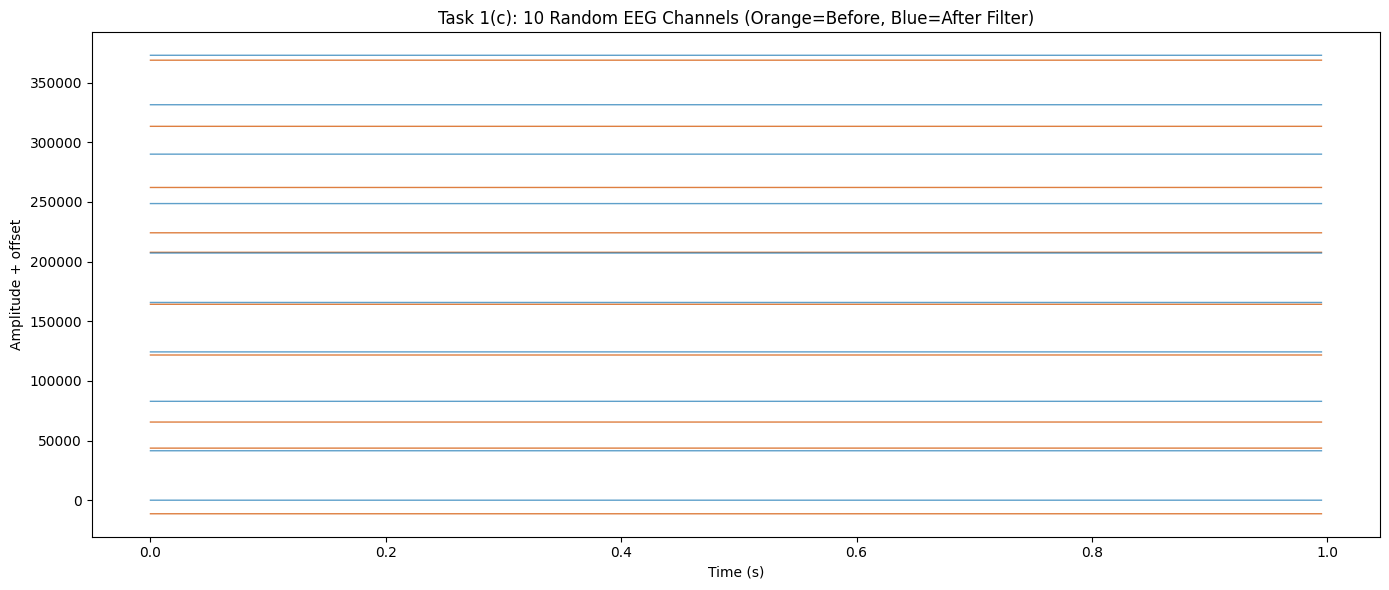

Final preprocessed shape: (3000, 64, 200)
Label distribution (0/1): [1450 1550]


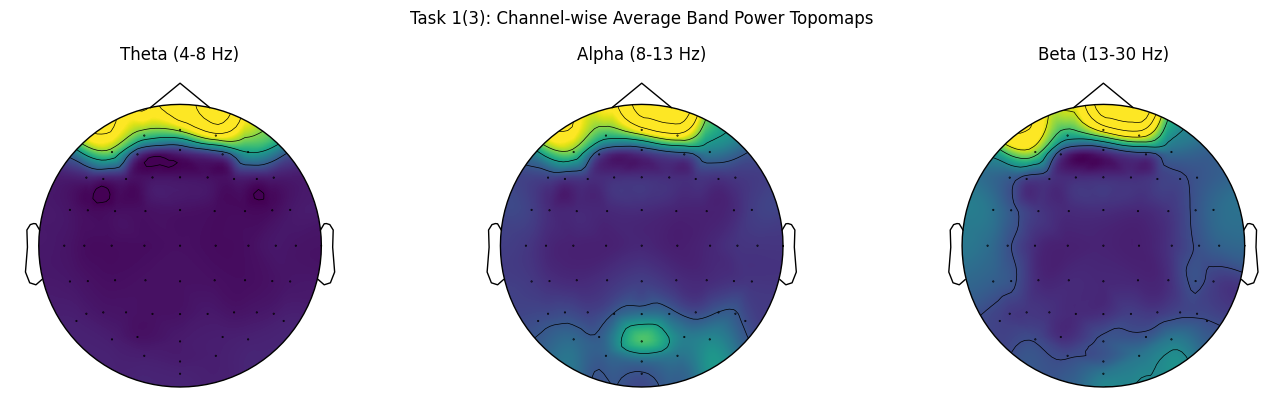

In [ ]:
# Run all tasks and print results
# Execute this cell after running previous definition cells.

# 1) Task 1 preprocessing and visual analysis
X_prep, y, epochs, info, sfreq = run_task1_preprocessing('S2.mat', random_state=42)
band_power = run_task1_feature_analysis(X_prep, info, sfreq)

# 2) Task 2 SVM baselines
svm_out = run_task2_svm(X_prep, y)

# 3) Task 3 foundation-model baseline
fm_model, fm_hist, fm_best_acc = run_task3_train_fm_baseline(
    X_prep, y, epochs=20, batch_size=64, lr=1e-3
)

# 4) Task 4 advanced model exploration
adv_model, adv_hist, adv_best_acc = run_task4_train_advanced(
    X_prep, y, epochs=20, batch_size=64, lr=8e-4
)

print('===== Summary =====')
print(f"Task2 best SVM: {svm_out['best_kernel']} ({svm_out['best_acc']:.4f})")
print(f"Task3 FM best test acc: {fm_best_acc:.4f}")
print(f"Task4 Advanced best test acc: {adv_best_acc:.4f}")
